# 2. Entrenamiento y Evaluación del Modelo
## 2.1 Configuración para Datos Desbalanceados

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                            recall_score, precision_score, f1_score, roc_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos procesados
X = pd.read_csv('../data/X_processed.csv')
y = pd.read_csv('../data/y_target.csv').values.ravel()
y_modes = pd.read_csv('../data/y_failure_modes.csv')

# Limpiar nombres de características para XGBoost
# XGBoost no permite caracteres como [, ], <, > en los nombres
def clean_feature_names(df):
    """Limpiar los nombres de las características para cumplir con los
    requisitos de XGBoost"""
    df_clean = df.copy()
    df_clean.columns = [col.replace('[', '').replace(']', '').replace('<', '')
                        .replace('>', '').replace(' ', '_').strip() 
                        for col in df_clean.columns]
    return df_clean

X_clean = clean_feature_names(X)

# Verificar nombres limpios
print("Nombres de características limpios:")
print(X_clean.columns.tolist())

# División train/test estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=73, stratify=y
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Distribución Train: {np.mean(y_train):.3f}")
print(f"Distribución Test: {np.mean(y_test):.3f}")

Nombres de características limpios:
['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Temp_Diff', 'Power', 'Thermal_Efficiency', 'Wear_Torque_Interaction', 'Speed_Deviation', 'Type_H', 'Type_L', 'Type_M']

Train: (8000, 13), Test: (2000, 13)
Distribución Train: 0.034
Distribución Test: 0.034


## 2.2 Entrenamiento con SMOTE y Modelos

In [3]:
# Función para crear pipeline con SMOTE
def create_smote_pipeline(model):
    """Crea un pipeline con SMOTE y el modelo especificado"""
    return ImbPipeline([
        ('smote', SMOTE(random_state=73, sampling_strategy=0.3)),
        ('classifier', model)
    ])

# Modelos con parámetros ajustados
models = {
    'XGBoost': XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=73,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=73,
        n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=73,
        class_weight='balanced',
        solver='liblinear'
    )
}

# Evaluar modelos con validación cruzada
results = {}
for name, model in models.items():
    print(f"\nEntrenando {name}...")

    try:
        pipeline = create_smote_pipeline(model)

        # Cross-validation con recall como métrica principal
        cv_scores = cross_val_score(
            pipeline, X_train, y_train, cv=5,
            scoring='recall', n_jobs=-1, error_score='raise'
        )

        print(f"    CV Recall: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")

        # Entrenar en todo el set de entrenamiento
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]

        # Calcular métricas
        results[name] = {
            'cv_recall_mean': cv_scores.mean(),
            'cv_recall_std': cv_scores.std(),
            'test_recall': recall_score(y_test, y_pred),
            'test_precision': precision_score(y_test, y_pred),
            'test_f1': f1_score(y_test, y_pred),
            'test_auc': roc_auc_score(y_test, y_proba)
        }
    except Exception as e:
        print(f"    Error con {name}: {str(e)}")
        continue

# Mostrar resultados
if results:
    results_df = pd.DataFrame(results).T.round(3)
    print("\n" + "="*60)
    print("RESULTADOS DE MODELOS")
    print("="*60)
    print(results_df)

    # Guardar mejor modelo
    best_model_name = results_df['test_recall'].idxmax()
    best_model = create_smote_pipeline(models[best_model_name])
    best_model.fit(X_train, y_train)

    print("\n" + "="*60)
    print(f"MEJOR MODELO: {best_model_name}")
    print(f"    Recall en test: {results_df.loc[best_model_name, 'test_recall']:.3f}")
    print(f"    Precisión en test: {results_df.loc[best_model_name, 'test_precision']:.3f}")
    print(f"    F1-Score en test: {results_df.loc[best_model_name, 'test_f1']:.3f}")
    print(f"    AUC-ROC en test: {results_df.loc[best_model_name, 'test_auc']:.3f}")

    print("="*60)

else:
    print("No se pudo entrenar ningún modelo correctamente.")


Entrenando XGBoost...
    CV Recall: 0.808 (±0.048)

Entrenando Random Forest...
    CV Recall: 0.823 (±0.053)

Entrenando Logistic Regression...
    CV Recall: 0.815 (±0.035)

RESULTADOS DE MODELOS
                     cv_recall_mean  cv_recall_std  test_recall  \
XGBoost                       0.808          0.048        0.868   
Random Forest                 0.823          0.053        0.868   
Logistic Regression           0.815          0.035        0.853   

                     test_precision  test_f1  test_auc  
XGBoost                       0.756    0.808     0.991  
Random Forest                 0.797    0.831     0.990  
Logistic Regression           0.162    0.272     0.932  

MEJOR MODELO: XGBoost
    Recall en test: 0.868
    Precisión en test: 0.756
    F1-Score en test: 0.808
    AUC-ROC en test: 0.991


## 2.3 Análisis del Mejor Modelo

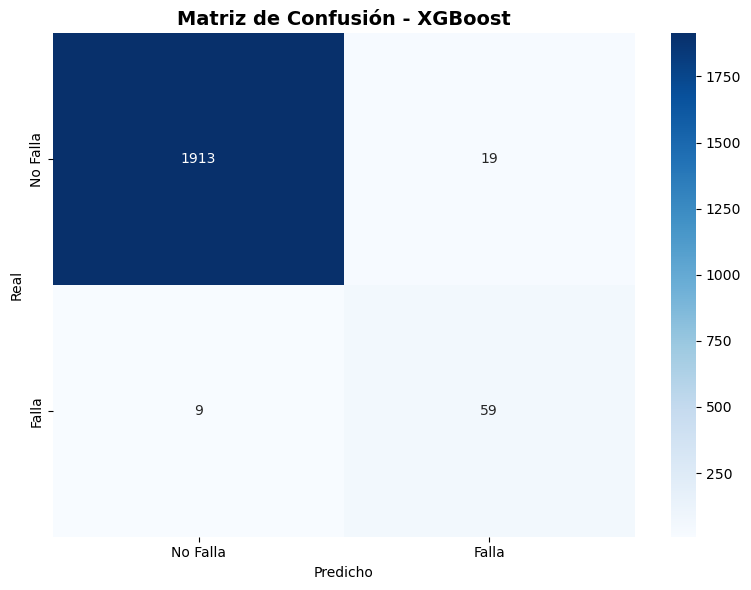


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1932
           1       0.76      0.87      0.81        68

    accuracy                           0.99      2000
   macro avg       0.88      0.93      0.90      2000
weighted avg       0.99      0.99      0.99      2000



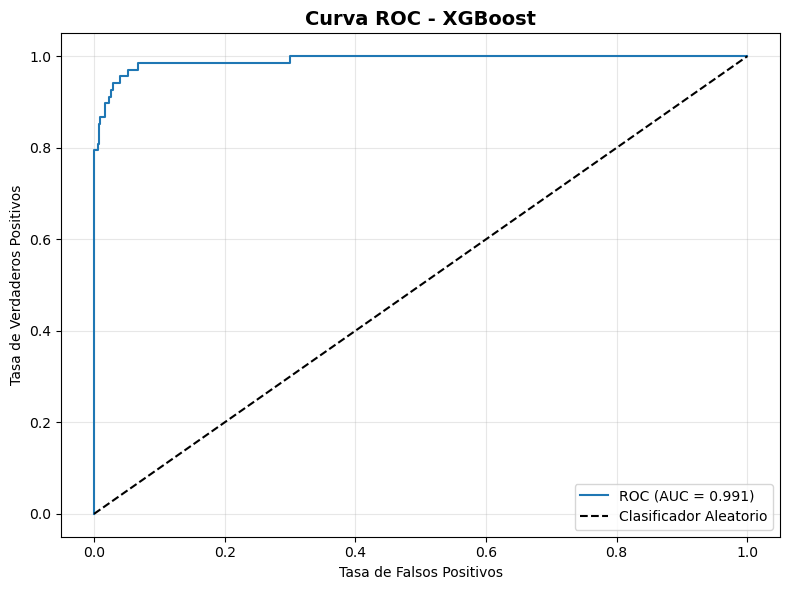

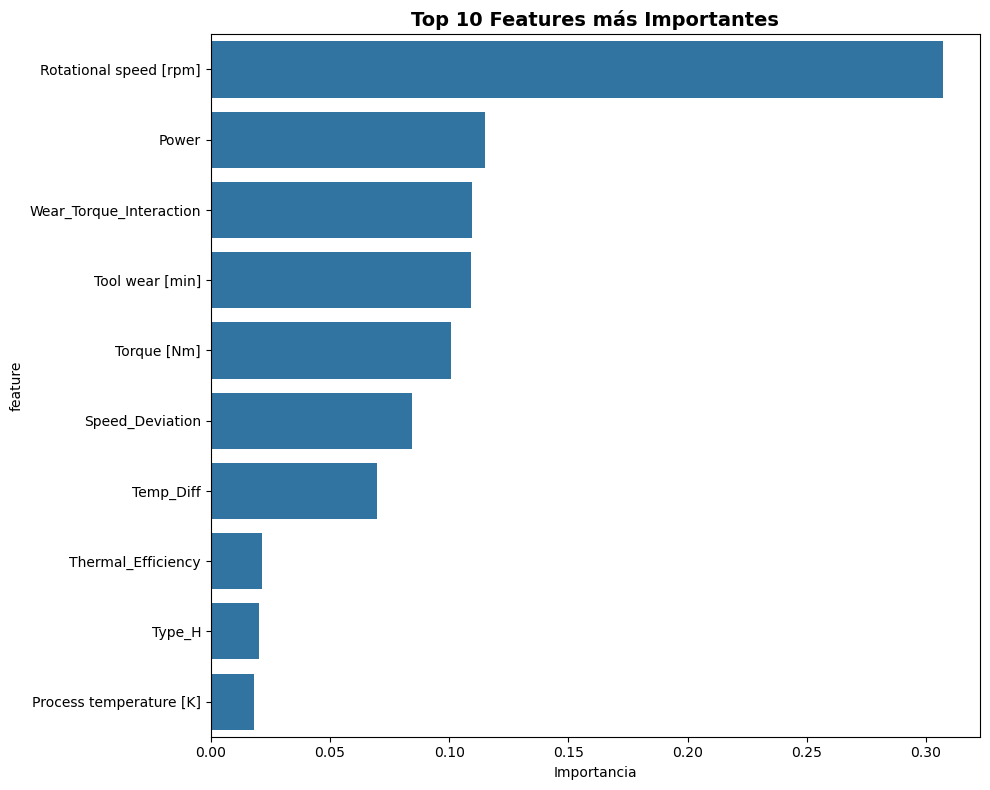

['../models/best_model.pkl']

In [7]:
# Predicciones del mejor modelo
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Falla', 'Falla'],
            yticklabels=['No Falla', 'Falla'])
plt.title(f'Matriz de Confusión - {best_model_name}', fontsize=14, 
            fontweight='bold')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', dpi=300,
            bbox_inches='tight')
plt.show()

# Reporte de clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_best))

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_best)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc_score(y_test, y_proba_best):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title(f'Curva ROC - {best_model_name}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Importancia de características
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.named_steps['classifier'].feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Features más Importantes', fontsize=14, fontweight='bold')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=300,
            bbox_inches='tight')
plt.show()

# Guardar modelo
import joblib
joblib.dump(best_model, '../models/best_model.pkl')